In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_auc_score, roc_curve, precision_recall_curve
)

# Professional plotting style
plt.style.use('ggplot')
%matplotlib inline

In [2]:
# Load dataset
df = pd.read_csv("Loan_default.csv")

# 🚩 FIX: Drop Unique Identifiers to prevent MemoryError (60GB issue)
# If your CSV has a 'LoanID' or 'ID' column, it must be dropped.
if 'LoanID' in df.columns:
    df = df.drop(columns=['LoanID'])

# Remove duplicates
df = df.drop_duplicates()

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (255347, 17)


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


# Handling Missing Values & Outliers

In [3]:
# Identify column types
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
if 'Default' in num_cols: num_cols.remove('Default')
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

# 1. Fill Missing Values
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna("unknown")

# 2. Standardize Text
for col in cat_cols:
    df[col] = df[col].str.lower().str.strip()

# 3. Robust Outlier Handling (Capping at 1.5 * IQR)
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)

print("Data cleaning and outlier capping complete.")

Data cleaning and outlier capping complete.


In [4]:
# We use LabelEncoder to keep the feature count consistent for the Web App
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    # Save each encoder separately for the Flask App
    joblib.dump(le, f"{col}_encoder.pkl")
    encoders[col] = le

print("Categorical encoders saved for app.py")

Categorical encoders saved for app.py


In [5]:
X = df.drop("Default", axis=1)
y = df["Default"]

# Stratified split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler for the Flask App
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [6]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs"]
}

grid = GridSearchCV(log_reg, param_grid, scoring="roc_auc", cv=5, n_jobs=-1)
grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_
joblib.dump(best_model, "log_regression.pkl")

print(f"Best Parameters: {grid.best_params_}")

Best Parameters: {'C': 0.01, 'solver': 'lbfgs'}


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.67      0.78     45139
           1       0.22      0.70      0.33      5931

    accuracy                           0.67     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.67      0.73     51070

ROC-AUC Score: 0.7498


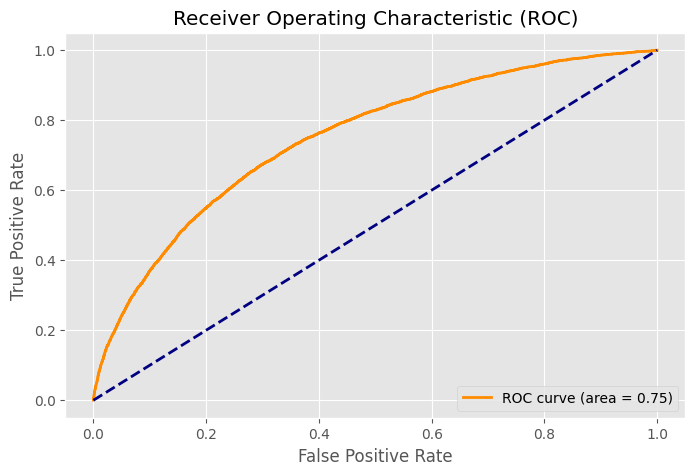

In [7]:
# Predictions
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Plotting ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

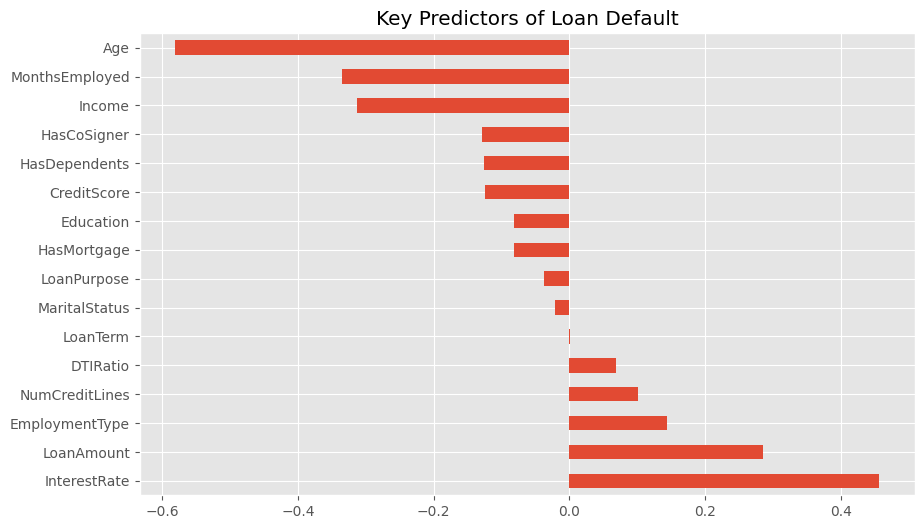

In [8]:
# Displaying which features drive the prediction most
feature_importance = pd.Series(
    best_model.coef_[0],
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='barh')
plt.title("Key Predictors of Loan Default")
plt.show()